# Preparación del dataset para modelado de calidad de agua

Este notebook documenta la preparación del conjunto de datos que será utilizado para entrenar modelos de aprendizaje supervisado orientados a la estimación de parámetros de calidad de agua en humedales.

En esta etapa se carga el archivo espacial integrado generado previamente, se define la variable objetivo, se seleccionan las variables predictoras, se configura la transformación logarítmica del parámetro de interés y se construyen las matrices de modelado.

El dataset preparado en este notebook será utilizado posteriormente por los modelos:

- Support Vector Regression (SVR),
- Gradient Boosting Regressor (GBR),
- Random Forest Regressor (RFR).

## Objetivo

Preparar el dataset de modelado a partir del archivo integrado de reflectancias, índices espectrales y parámetros de laboratorio.

El flujo incluye:

1. carga del archivo espacial integrado,
2. revisión de las columnas disponibles,
3. definición de la variable objetivo,
4. selección de variables predictoras,
5. configuración de la transformación logarítmica,
6. limpieza de datos,
7. separación entre variables predictoras (`X`) y variable objetivo (`y`),
8. generación y almacenamiento del split de entrenamiento y prueba.

In [1]:
from pathlib import Path
import sys

BASE_DIR = Path.cwd()

while not (BASE_DIR / "src").exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent

sys.path.append(str(BASE_DIR))

print("BASE_DIR detectado:")
print(BASE_DIR)

BASE_DIR detectado:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales


## Importación de funciones auxiliares

Se importan las funciones definidas en `src/calidad_agua/preparacion.py`.

Estas funciones permiten centralizar la lógica de carga del dataset, validación de columnas, limpieza de datos, aplicación de transformación logarítmica y generación del split de entrenamiento y prueba.

In [2]:
from src.calidad_agua.preparacion import (
    cargar_dataset_modelo,
    preparar_dataset,
    crear_y_guardar_split,
    obtener_columnas_logaritmicas_disponibles,
    obtener_target_salida,
    calcular_matriz_correlacion,
    guardar_matriz_correlacion,
    graficar_matriz_correlacion
)

## Carga del archivo integrado

Se carga el archivo espacial integrado generado en la etapa de extracción de variables espectrales.

La lectura y conversión a `DataFrame` se realiza mediante la función `cargar_dataset_modelo()`, definida en `src/calidad_agua/preparacion.py`. Esta función valida la existencia del archivo, verifica que no esté vacío y elimina la geometría para generar una tabla de trabajo apta para modelado.

In [3]:
ruta_datos_modelo = BASE_DIR / "data" / "processed" / "calidad_agua" / "Puntos_Muestreo_Reflectancia_Indices_Excel_2.gpkg"

df_modelo = cargar_dataset_modelo(ruta_datos_modelo)

print("Archivo cargado correctamente:")
print(ruta_datos_modelo)

print("\nDimensiones del DataFrame de trabajo:")
print(df_modelo.shape)

Archivo cargado correctamente:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\data\processed\calidad_agua\Puntos_Muestreo_Reflectancia_Indices_Excel_2.gpkg

Dimensiones del DataFrame de trabajo:
(78, 28)


## Revisión de columnas disponibles

Antes de definir el modelo, se revisan las columnas disponibles en el dataset integrado. Esto permite identificar las variables espectrales, índices calculados y parámetros de laboratorio disponibles para el modelado.

In [4]:
df_modelo.columns.tolist()

['Name',
 'Blue',
 'Green',
 'Pan',
 'Red',
 'RedEdge',
 'NIR',
 'NDVI',
 'NDWI',
 'ID_Muestra',
 'DQO',
 'pH',
 'Fosfatos',
 'CE',
 'Turbidez',
 'Nitratos',
 'Sulfatos',
 'ficocianin',
 'Chl',
 'EVI',
 'SAVI',
 'GNDVI',
 'VARI',
 'NDRE',
 'CIgreen',
 'CIRE',
 'ARI',
 'RENDVI']

## Vista preliminar del dataset

Se visualizan los primeros registros del DataFrame de trabajo para verificar la estructura general de la tabla y confirmar que las variables esperadas fueron cargadas correctamente.

In [5]:
df_modelo.head()

,Name,Blue,Green,Pan,Red,RedEdge,NIR,NDVI,NDWI,ID_Muestra,...,Chl,EVI,SAVI,GNDVI,VARI,NDRE,CIgreen,CIRE,ARI,RENDVI
0,P1,489.892562,1159.471074,1179.413223,486.677686,1899.545455,3129.115702,0.730809,14.825766,P1,...,1.488,2.800937,1.096061,0.459203,0.582500,0.244585,1.699734,0.649299,0.000336,0.244585
1,P10,586.363636,1080.785124,1050.330579,563.983471,1493.404959,1553.661157,0.467125,24.711568,P10,...,2.123,5.146086,0.700522,0.179125,0.489188,4.653179,0.438030,0.041702,0.000255,4.653179
2,P11,632.107438,1180.950413,1121.173554,611.074380,1570.917355,1415.462810,0.396869,25.163323,P11,...,2.648,10.426632,0.595157,0.090017,0.492344,21.199901,0.199190,-0.097747,0.000210,21.199901
3,P12,579.049587,1089.438017,1040.793388,571.107438,1439.859504,1437.528926,0.431036,25.820756,P12,...,0.745,3.961932,0.646394,0.137234,0.480169,12.122226,0.320156,-0.000287,0.000223,12.122226
4,P13,584.429752,1094.008264,1073.256198,558.429752,1457.057851,1684.991736,0.502005,23.382608,P13,...,1.737,5.053165,0.752840,0.212414,0.502150,0.072510,0.540954,0.157973,0.000227,0.072510


## Definición de la variable objetivo

En esta sección se define el parámetro de calidad de agua que será estimado por los modelos.

El valor de `target` puede modificarse para entrenar modelos sobre otros parámetros disponibles en el dataset, siempre que la columna correspondiente exista en el archivo integrado.

In [6]:
# ============================================================
# CONFIGURACIÓN DE VARIABLE OBJETIVO
# ============================================================

# Variables disponibles en escala original:
# "DQO", "Fosfatos", "Turbidez", "Nitratos", "Sulfatos",
# "ficocianin", "Chl", "CE", "pH"

# Variables disponibles transformadas:
# "ln_DQO", "ln_Fosfatos", "ln_Turbidez", "ln_Nitratos",
# "ln_Sulfatos", "ln_ficocianin", "ln_Chl", "ln_CE"
#
# Nota:
# pH se conserva en escala original porque ya corresponde a una escala logarítmica.

target_modelo = "ln_DQO"

target_salida = obtener_target_salida(target_modelo)

print("Variable objetivo usada para modelado:")
print(target_modelo)

print("\nNombre limpio para carpetas y salidas:")
print(target_salida)

Variable objetivo usada para modelado:
ln_DQO

Nombre limpio para carpetas y salidas:
DQO


## Definición de variables predictoras

Las variables predictoras corresponden a reflectancias por banda e índices espectrales derivados del ortomosaico multibanda.

Estas variables serán utilizadas como entrada para los modelos SVR, Gradient Boosting Regressor y Random Forest Regressor.

In [7]:
vars_pred = [
    "Blue",
    "Green",
    "Pan",
    "Red",
    "RedEdge",
    "NIR",
    "NDVI",
    "NDWI",
    "EVI",
    "SAVI",
    "GNDVI",
    "VARI",
    "NDRE",
    "CIgreen",
    "CIRE",
    "ARI",
    "RENDVI"
]

print("Número de variables predictoras:")
print(len(vars_pred))

print("\nVariables predictoras:")
print(vars_pred)

Número de variables predictoras:
17

Variables predictoras:
['Blue', 'Green', 'Pan', 'Red', 'RedEdge', 'NIR', 'NDVI', 'NDWI', 'EVI', 'SAVI', 'GNDVI', 'VARI', 'NDRE', 'CIgreen', 'CIRE', 'ARI', 'RENDVI']


## Configuración de transformación logarítmica

Durante la exploración experimental del flujo de modelado se observó que los algoritmos pueden presentar mejor comportamiento cuando el parámetro de calidad de agua se transforma mediante logaritmo natural.

Por esta razón, el flujo queda configurado por defecto para trabajar con la variable objetivo transformada. Sin embargo, esta decisión debe poder ajustarse según el comportamiento de nuevos datos o nuevos parámetros.

En la siguiente celda se dejan dos opciones:

- **Opción A:** usar transformación logarítmica natural.
- **Opción B:** trabajar sin transformación.

Para cambiar entre una y otra, basta con comentar o descomentar las líneas indicadas.

In [8]:
# ============================================================
# CONFIGURACIÓN DE TRANSFORMACIÓN LOGARÍTMICA
# ============================================================

# Columnas de parámetros de calidad de agua usadas para crear variables ln_.
param_cols_log = [
    "DQO",
    "Fosfatos",
    "Turbidez",
    "Nitratos",
    "Sulfatos",
    "ficocianin",
    "Chl",
    "CE"
]

# Valor usado cuando el dato original es nulo, cero o negativo.
valor_reemplazo_log = 0.3

# Crear columnas logarítmicas ln_.
# Mantener True si se desea trabajar con variables como ln_DQO, ln_Fosfatos, etc.
crear_ln = True

# Si se desea trabajar únicamente con variables originales, puede usarse:
# crear_ln = False
# target_modelo = "DQO"
# target_salida = obtener_target_salida(target_modelo)

print("¿Crear columnas logarítmicas?")
print(crear_ln)

print("\nColumnas base para transformación logarítmica:")
print(param_cols_log)

print("\nValor de reemplazo para datos nulos, cero o negativos:")
print(valor_reemplazo_log)

¿Crear columnas logarítmicas?
True

Columnas base para transformación logarítmica:
['DQO', 'Fosfatos', 'Turbidez', 'Nitratos', 'Sulfatos', 'ficocianin', 'Chl', 'CE']

Valor de reemplazo para datos nulos, cero o negativos:
0.3


## Verificación de columnas logarítmicas

En esta sección se revisan las columnas logarítmicas que serán generadas a partir de los parámetros de calidad de agua.

Estas columnas no reemplazan las variables originales; se agregan al dataset con el prefijo `ln_`.

In [9]:
# Esta verificación se hace sobre los nombres esperados.
columnas_ln_esperadas = [f"ln_{col}" for col in param_cols_log]

print("Columnas logarítmicas esperadas:")
print(columnas_ln_esperadas)

Columnas logarítmicas esperadas:
['ln_DQO', 'ln_Fosfatos', 'ln_Turbidez', 'ln_Nitratos', 'ln_Sulfatos', 'ln_ficocianin', 'ln_Chl', 'ln_CE']


## Preparación del dataset

Se ejecuta la preparación del dataset mediante la función `preparar_dataset()`.

Esta función realiza:

1. validación de la existencia de la variable objetivo y las variables predictoras,
2. aplicación opcional del logaritmo natural,
3. limpieza de registros con valores faltantes o infinitos,
4. separación entre variables predictoras (`X`) y variable objetivo (`y`).

Si `aplicar_log = True`, el vector `y` quedará expresado en escala logarítmica natural. En ese caso, los modelos se entrenarán sobre dicha escala y las predicciones espaciales deberán transformarse posteriormente a escala original mediante la función exponencial.

In [10]:
# ============================================================
# CONFIGURACIÓN DE REGISTROS
# ============================================================

# El notebook original trabajó con los primeros 65 registros.
# Usar None si se desea conservar todos los registros del dataset.
n_registros = 65

X, y, df_modelo_preparado = preparar_dataset(
    df=df_modelo,
    target=target_modelo,
    vars_pred=vars_pred,
    n_registros=n_registros,
    param_cols_log=param_cols_log,
    crear_ln=crear_ln,
    valor_reemplazo_log=valor_reemplazo_log
)

print("Dataset preparado correctamente.")

print("\nRegistros usados:")
print(n_registros)

print("\nDimensiones de X:")
print(X.shape)

print("\nDimensiones de y:")
print(y.shape)

print("\nDimensiones del DataFrame preparado:")
print(df_modelo_preparado.shape)

Dataset preparado correctamente.

Registros usados:
65

Dimensiones de X:
(65, 17)

Dimensiones de y:
(65,)

Dimensiones del DataFrame preparado:
(65, 36)


In [11]:
columnas_ln_disponibles = obtener_columnas_logaritmicas_disponibles(
    df=df_modelo_preparado,
    param_cols=param_cols_log
)

print("Columnas logarítmicas disponibles en el DataFrame preparado:")
print(columnas_ln_disponibles)

Columnas logarítmicas disponibles en el DataFrame preparado:
['ln_DQO', 'ln_Fosfatos', 'ln_Turbidez', 'ln_Nitratos', 'ln_Sulfatos', 'ln_ficocianin', 'ln_Chl', 'ln_CE']


## Interpretación preliminar

Las matrices de correlación permiten identificar asociaciones lineales entre variables espectrales, índices derivados y parámetros de calidad de agua.

Valores cercanos a `1` indican asociación positiva fuerte, valores cercanos a `-1` indican asociación negativa fuerte y valores cercanos a `0` indican baja asociación lineal.

Es importante considerar que:

- una correlación alta no implica causalidad;
- variables altamente correlacionadas entre sí pueden aportar información redundante;
- una baja correlación lineal no descarta relaciones no lineales;
- la transformación logarítmica puede modificar la relación aparente entre variables;
- estas matrices son una herramienta exploratoria y deben interpretarse junto con la evaluación de los modelos.

## Revisión de las variables predictoras

Se revisa una muestra de la matriz `X`, que contiene las variables predictoras que serán utilizadas por los modelos.

In [12]:
X.head()

,Blue,Green,Pan,Red,RedEdge,NIR,NDVI,NDWI,EVI,SAVI,GNDVI,VARI,NDRE,CIgreen,CIRE,ARI,RENDVI
0,489.892562,1159.471074,1179.413223,486.677686,1899.545455,3129.115702,0.730809,14.825766,2.800937,1.096061,0.459203,0.582500,0.244585,1.699734,0.649299,0.000336,0.244585
1,586.363636,1080.785124,1050.330579,563.983471,1493.404959,1553.661157,0.467125,24.711568,5.146086,0.700522,0.179125,0.489188,4.653179,0.438030,0.041702,0.000255,4.653179
2,632.107438,1180.950413,1121.173554,611.074380,1570.917355,1415.462810,0.396869,25.163323,10.426632,0.595157,0.090017,0.492344,21.199901,0.199190,-0.097747,0.000210,21.199901
3,579.049587,1089.438017,1040.793388,571.107438,1439.859504,1437.528926,0.431036,25.820756,3.961932,0.646394,0.137234,0.480169,12.122226,0.320156,-0.000287,0.000223,12.122226
4,584.429752,1094.008264,1073.256198,558.429752,1457.057851,1684.991736,0.502005,23.382608,5.053165,0.752840,0.212414,0.502150,0.072510,0.540954,0.157973,0.000227,0.072510


## Revisión de la variable objetivo

Se revisa una muestra del vector `y`. Si la transformación logarítmica está activa, estos valores corresponden al parámetro objetivo en escala logarítmica natural.

In [13]:
y.head()

0    4.543295
1    4.543295
2    4.727388
3    4.543295
4    4.543295
Name: ln_DQO, dtype: float64

## Matrices de correlación

Antes del entrenamiento se generan dos matrices de correlación para explorar las relaciones entre variables espectrales, índices derivados y parámetros de calidad de agua:

- una matriz con parámetros en escala original;
- una matriz con parámetros transformados mediante logaritmo natural (`ln_`).

Estas matrices permiten comparar si la transformación logarítmica modifica la estructura de asociación entre las variables. Su interpretación es exploratoria: una correlación alta no implica causalidad, y una baja correlación lineal no descarta relaciones no lineales.

Matriz de correlación guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\tables\calidad_agua\DQO\matriz_correlacion_original.csv
Matriz de correlación guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\tables\calidad_agua\DQO\matriz_correlacion_transformada.csv
Figura de matriz de correlación guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\figures\calidad_agua\DQO\matriz_correlacion_original.png


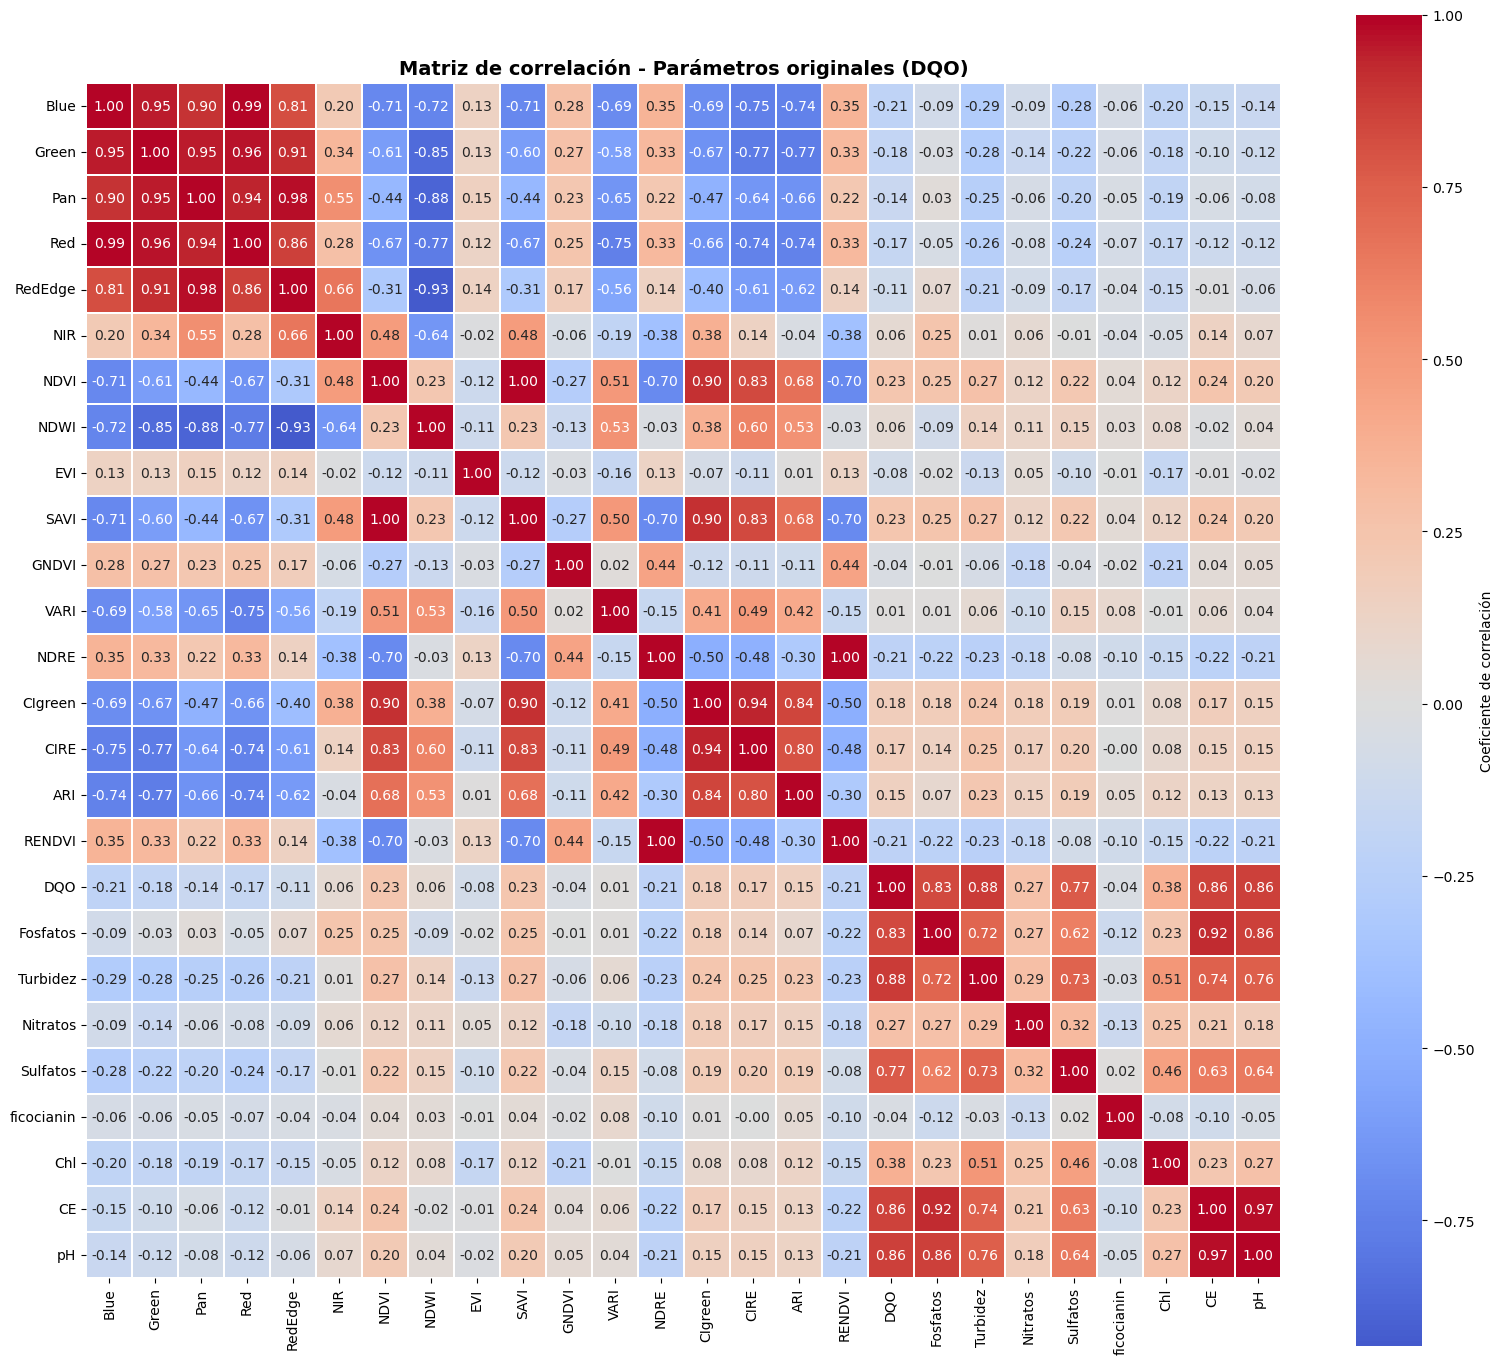

Figura de matriz de correlación guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\figures\calidad_agua\DQO\matriz_correlacion_transformada.png


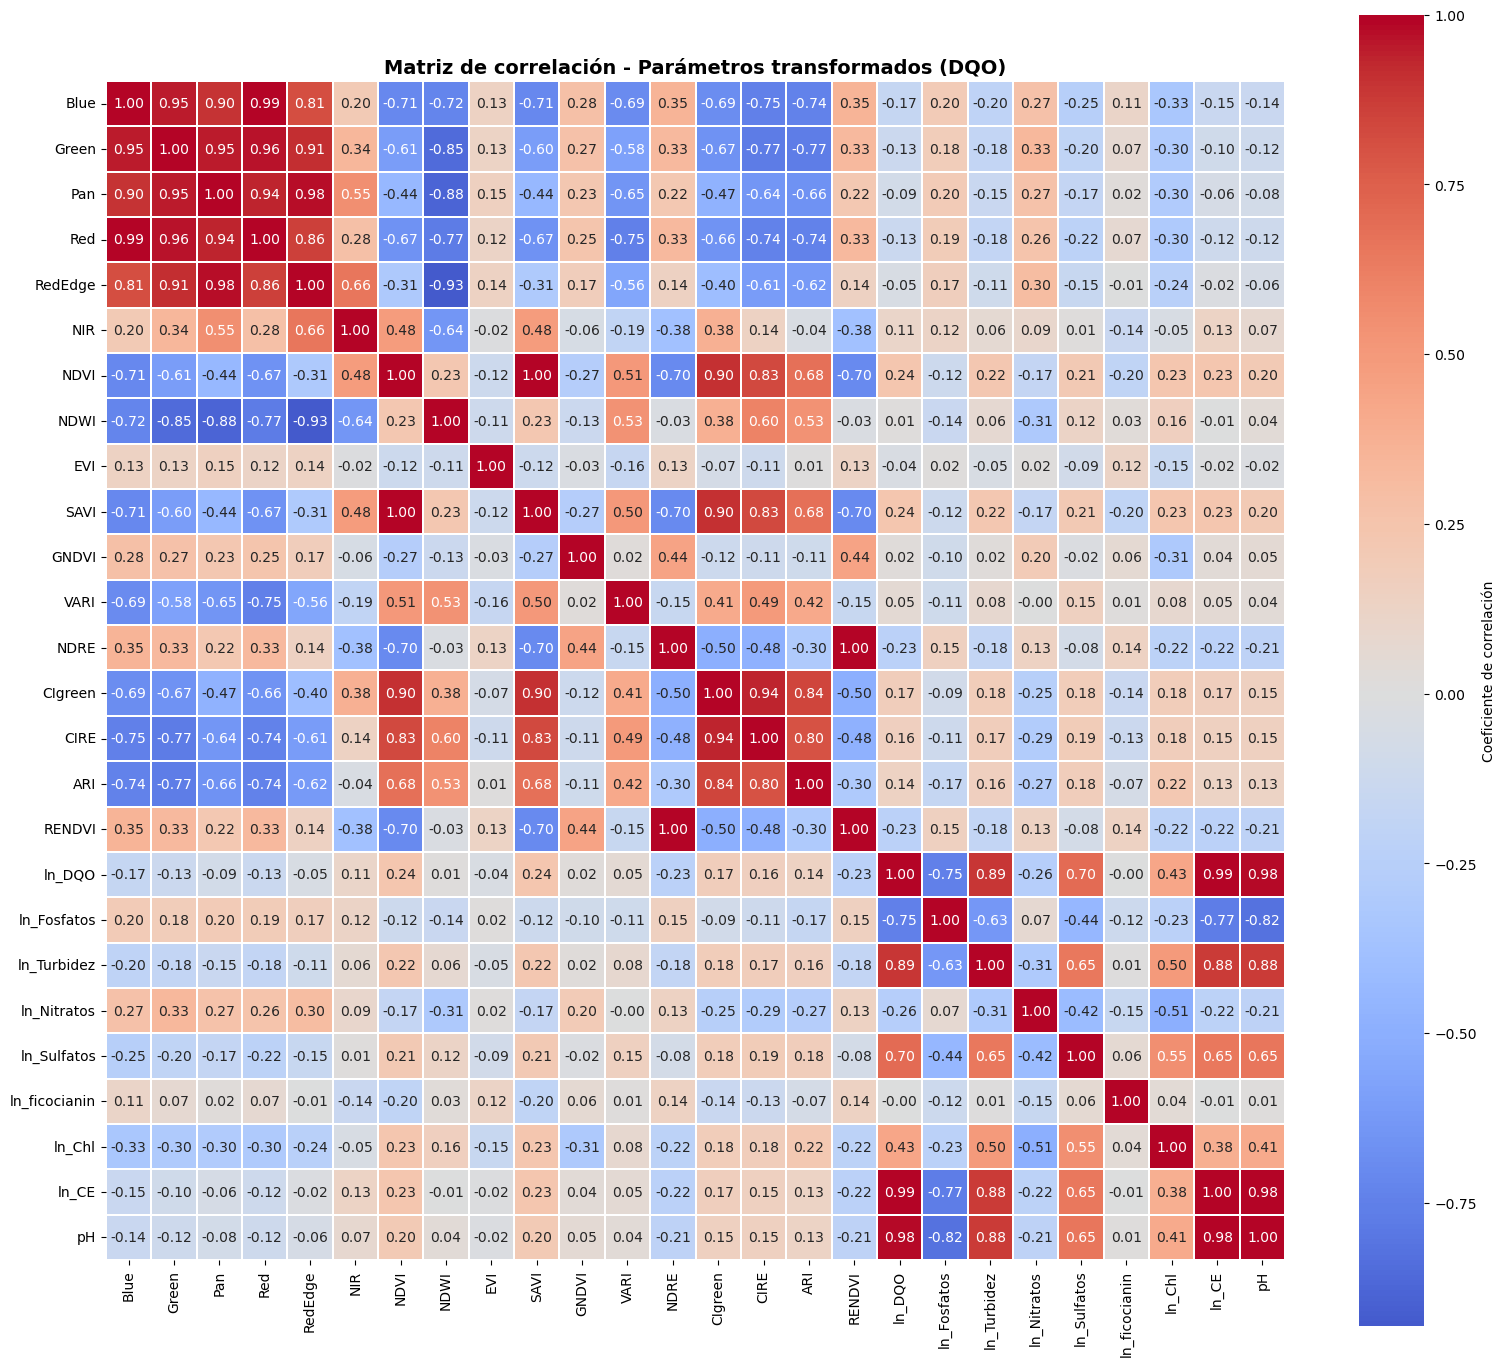

Matrices de correlación generadas correctamente.


In [14]:
# ============================================================
# MATRICES DE CORRELACIÓN
# ============================================================

param_cols_originales = [
    "DQO",
    "Fosfatos",
    "Turbidez",
    "Nitratos",
    "Sulfatos",
    "ficocianin",
    "Chl",
    "CE",
    "pH"
]

param_cols_transformadas = [
    "ln_DQO",
    "ln_Fosfatos",
    "ln_Turbidez",
    "ln_Nitratos",
    "ln_Sulfatos",
    "ln_ficocianin",
    "ln_Chl",
    "ln_CE",
    "pH"
]

cols_corr_original = vars_pred + param_cols_originales
cols_corr_transformada = vars_pred + param_cols_transformadas

carpeta_tablas_corr = BASE_DIR / "outputs" / "tables" / "calidad_agua" / target_salida
carpeta_figuras_corr = BASE_DIR / "outputs" / "figures" / "calidad_agua" / target_salida

# Matrices de correlación
matriz_corr_original = calcular_matriz_correlacion(
    df=df_modelo_preparado,
    columnas=cols_corr_original,
    metodo="pearson"
)

matriz_corr_transformada = calcular_matriz_correlacion(
    df=df_modelo_preparado,
    columnas=cols_corr_transformada,
    metodo="pearson"
)

# Guardado CSV
guardar_matriz_correlacion(
    matriz_corr=matriz_corr_original,
    ruta_salida=carpeta_tablas_corr / "matriz_correlacion_original.csv"
)

guardar_matriz_correlacion(
    matriz_corr=matriz_corr_transformada,
    ruta_salida=carpeta_tablas_corr / "matriz_correlacion_transformada.csv"
)

# Guardado PNG
graficar_matriz_correlacion(
    matriz_corr=matriz_corr_original,
    titulo=f"Matriz de correlación - Parámetros originales ({target_salida})",
    ruta_salida=carpeta_figuras_corr / "matriz_correlacion_original.png",
    cmap="coolwarm",
    annot=True,
    figsize=(16, 14)
)

graficar_matriz_correlacion(
    matriz_corr=matriz_corr_transformada,
    titulo=f"Matriz de correlación - Parámetros transformados ({target_salida})",
    ruta_salida=carpeta_figuras_corr / "matriz_correlacion_transformada.png",
    cmap="coolwarm",
    annot=True,
    figsize=(16, 14)
)

print("Matrices de correlación generadas correctamente.")

## Configuración del split de entrenamiento y prueba

Se define la proporción de datos destinada a prueba (`test_size`) y la semilla aleatoria (`random_state`) para garantizar reproducibilidad.

El mismo split será utilizado por los tres modelos:

- SVR,
- Gradient Boosting Regressor,
- Random Forest Regressor.

Esto permite que la comparación de métricas entre modelos sea consistente, ya que todos se evaluarán sobre los mismos datos de entrenamiento y prueba.

In [15]:
test_size = 0.15
random_state = 42

ruta_split = BASE_DIR / "data" / "interim" / "calidad_agua" / "splits" / f"split_{target_salida}.joblib"

print("Ruta del split:")
print(ruta_split)

Ruta del split:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\data\interim\calidad_agua\splits\split_DQO.joblib


## Creación y almacenamiento del split

Se crea el split de entrenamiento y prueba y se guarda en formato `.joblib`.

El archivo contiene:

- `X_train`,
- `X_test`,
- `y_train`,
- `y_test`,
- `target`,
- `vars_pred`,
- `aplicar_log`,
- `columnas_log`,
- `test_size`,
- `random_state`.

Guardar esta información permite que las etapas posteriores de entrenamiento, evaluación, interpretación e inferencia espacial utilicen exactamente la misma configuración de datos.

In [16]:
X_train, X_test, y_train, y_test = crear_y_guardar_split(
    X=X,
    y=y,
    ruta_split=ruta_split,
    target_modelo=target_modelo,
    target_salida=target_salida,
    vars_pred=vars_pred,
    crear_ln=crear_ln,
    param_cols_log=param_cols_log,
    valor_reemplazo_log=valor_reemplazo_log,
    n_registros=n_registros,
    test_size=test_size,
    random_state=random_state
)

print("Split generado correctamente.")

print("\nVariable objetivo usada para modelado:")
print(target_modelo)

print("\nNombre limpio para salidas:")
print(target_salida)

print("\nDimensiones:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Split guardado correctamente en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\data\interim\calidad_agua\splits\split_DQO.joblib
Split generado correctamente.

Variable objetivo usada para modelado:
ln_DQO

Nombre limpio para salidas:
DQO

Dimensiones:
X_train: (55, 17)
X_test: (10, 17)
y_train: (55,)
y_test: (10,)


## Producto de esta etapa

Al finalizar este notebook se obtiene un archivo `.joblib` con el split de entrenamiento y prueba, almacenado en:

`data/interim/calidad_agua/splits/`

Este archivo contiene tanto los conjuntos `X_train`, `X_test`, `y_train` y `y_test`, como metadatos del flujo:

- variable objetivo usada para modelado (`target_modelo`),
- nombre limpio para salidas (`target_salida`),
- variables predictoras,
- configuración de creación de columnas logarítmicas,
- número de registros usados,
- tamaño del conjunto de prueba,
- y semilla aleatoria.

Este archivo será utilizado por los notebooks posteriores para entrenar, evaluar, interpretar y aplicar espacialmente los modelos de manera reproducible.

## Consideraciones técnicas

- El notebook original creó columnas logarítmicas con el prefijo `ln_` para varios parámetros de calidad de agua.
- En este flujo se conserva esa lógica: las columnas originales no se reemplazan, sino que se crean columnas adicionales transformadas con logaritmo natural.
- Para valores nulos, cero o negativos se conserva el valor de reemplazo `0.3`, siguiendo la lógica del notebook original.
- El parámetro `pH` se conserva en escala original.
- Por defecto se conservan los primeros 65 registros, como en el flujo original. Si se desea usar todo el dataset, se debe definir `n_registros = None`.
- La variable objetivo usada por los modelos se define en `target_modelo`.
- Las carpetas y archivos de salida usan `target_salida`, de manera que un modelo entrenado con `ln_DQO` puede guardar productos bajo la carpeta `DQO`.

## Siguiente etapa del flujo

Una vez preparado el dataset y guardado el split de entrenamiento y prueba, el siguiente paso consiste en entrenar los modelos de aprendizaje supervisado.

Esta fase se documenta en:

`03_entrenamiento_modelos.ipynb`